# MuJoCo Quick Intro
A hands-on walkthrough of the MuJoCo concepts you'll need for HW2.

Run this notebook with the `.venv` kernel.

In [ ]:
import mujoco
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

## 1. Loading a Model

MuJoCo has two core objects:
- **`MjModel`** — the *blueprint*: joint types, link lengths, masses, actuator gains. Never changes.
- **`MjData`** — the *state*: current joint positions (`qpos`), velocities (`qvel`), forces, sensor readings. Changes every step.

In [4]:
ROOT = Path("/Users/shyngys/ethz/robot_learning/ethz-course-2026/hw2_robot_control_mdps")
XML_PATH = ROOT / "so101_gym" / "assets" / "so100_pos_ctrl.xml"

model = mujoco.MjModel.from_xml_path(str(XML_PATH))
data = mujoco.MjData(model)

print(f"Timestep:        {model.opt.timestep} s")
print(f"Num joints (nq): {model.nq}")
print(f"Num DoFs (nv):   {model.nv}")
print(f"Num actuators:   {model.nu}")

Timestep:        0.002 s
Num joints (nq): 6
Num DoFs (nv):   6
Num actuators:   6


## 2. Joint Names and Ranges

The SO-100 arm has 6 joints. Let's see them.

In [8]:
for i in range(model.njnt):
    jnt = model.joint(i)
    lo, hi = model.jnt_range[i]
    print(f"Joint {i}: {jnt.name:15s}  range [{np.degrees(lo):7.1f}, {np.degrees(hi):7.1f}] deg")

Joint 0: Rotation         range [ -110.0,   110.0] deg
Joint 1: Pitch            range [ -190.2,    10.0] deg
Joint 2: Elbow            range [  -10.0,   179.9] deg
Joint 3: Wrist_Pitch      range [  -95.1,    95.1] deg
Joint 4: Wrist_Roll       range [ -159.9,   159.9] deg
Joint 5: Jaw              range [  -10.0,   100.3] deg


## 3. `qpos` and `qvel` — the robot state

- `data.qpos` — joint **positions** (angles in radians)
- `data.qvel` — joint **velocities** (rad/s)

At the start, the robot is at the default pose (all zeros).

In [9]:
# Reset to default
mujoco.mj_resetData(model, data)
print("qpos (joint angles):", data.qpos)
print("qvel (joint velocities):", data.qvel)

qpos (joint angles): [0. 0. 0. 0. 0. 0.]
qvel (joint velocities): [0. 0. 0. 0. 0. 0.]


## 4. Forward Kinematics — where is the end-effector?

Given joint angles, MuJoCo computes where everything is in 3D space.

The robot has a **site** called `"ee_site"` at the end-effector (fingertip).

In [10]:
# Run forward kinematics to compute positions from joint angles
mujoco.mj_forward(model, data)

ee_pos = data.site("ee_site").xpos
print(f"End-effector position at default pose: {ee_pos}")

# Now change a joint and see how the EE moves
data.qpos[1] = -0.5  # tilt the shoulder (Pitch joint)
mujoco.mj_forward(model, data)
print(f"End-effector after tilting shoulder:    {data.site('ee_site').xpos}")

# Reset back
mujoco.mj_resetData(model, data)

End-effector position at default pose: [4.43370515e-01 1.62859084e-06 9.61982631e-02]
End-effector after tilting shoulder:    [4.09305200e-01 1.50346195e-06 2.75212061e-01]


## 5. Rendering a frame (without the viewer)

On macOS the interactive viewer needs `mjpython`, but we can render images directly in the notebook.

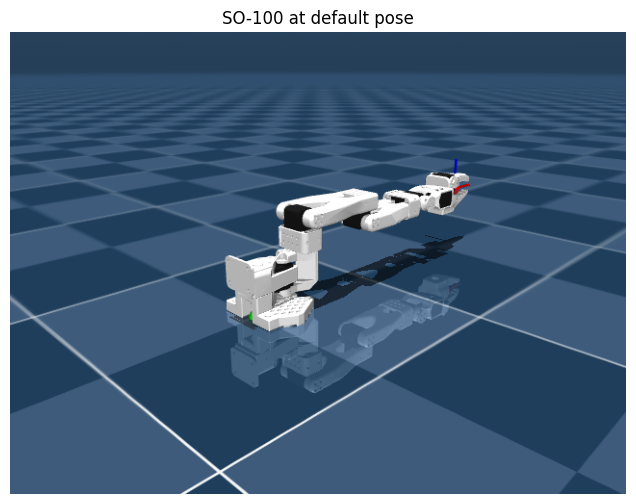

In [11]:
renderer = mujoco.Renderer(model, width=640, height=480)

mujoco.mj_forward(model, data)
renderer.update_scene(data)
img = renderer.render()

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("SO-100 at default pose")
plt.show()

## 6. Stepping the simulation

`mj_step` advances physics by one timestep (0.002s). To make the robot move, set `data.ctrl` (actuator commands).

This robot uses **position control** — `ctrl[i]` is the desired joint angle.

In [ ]:
mujoco.mj_resetData(model, data)

# Command: move shoulder to -0.8 rad, elbow to 1.0 rad
data.ctrl[1] = -0.8   # Pitch
data.ctrl[2] = 1.0    # Elbow

# Step 500 times = 1 second of simulation
for _ in range(500):
    mujoco.mj_step(model, data)

print(f"After 1s of simulation:")
print(f"  qpos: {np.round(data.qpos, 3)}")
print(f"  ctrl: {np.round(data.ctrl, 3)}")
print(f"  EE:   {np.round(data.site('ee_site').xpos, 4)}")

# Render the new pose
renderer.update_scene(data)
img = renderer.render()
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("After commanding shoulder=-0.8, elbow=1.0")
plt.show()

## 7. The Jacobian — how joints affect the end-effector

The Jacobian `J` is a matrix that tells you: *if I nudge each joint by a tiny amount, how does the end-effector move?*

It's the key ingredient for Inverse Kinematics.

In [ ]:
mujoco.mj_resetData(model, data)
mujoco.mj_forward(model, data)

# Compute the Jacobian at the end-effector site
jacp = np.zeros((3, model.nv))  # position part (3 x nv)
jacr = np.zeros((3, model.nv))  # rotation part (3 x nv)
site_id = model.site("ee_site").id
mujoco.mj_jacSite(model, data, jacp, jacr, site_id)

print("Position Jacobian (3 x nv):")
print("  Each column = how much EE [x,y,z] changes per radian of that joint")
print()
joint_names = [model.joint(i).name for i in range(model.njnt)]
for j in range(model.nv):
    print(f"  Joint '{joint_names[j]}': dx={jacp[0,j]:+.4f}  dy={jacp[1,j]:+.4f}  dz={jacp[2,j]:+.4f}")

## 8. Bodies, Sites, Actuators — key MuJoCo concepts

| Concept | What it is | Example |
|---------|-----------|--------|
| **Body** | A rigid link in the kinematic tree | `"Upper_Arm"`, `"Fixed_Jaw"` |
| **Joint** | Connects two bodies, allows relative motion | `"Rotation"`, `"Pitch"`, `"Elbow"` |
| **Geom** | Shape attached to a body (for collision/visual) | meshes, boxes, spheres |
| **Site** | A named point on a body (no physics, just a marker) | `"ee_site"` — the end-effector |
| **Actuator** | Controls a joint (position, torque, velocity) | `"Rotation"` actuator → `"Rotation"` joint |
| **`data.ctrl`** | Actuator command vector | `ctrl[0]` = desired angle for joint 0 |

In [ ]:
print("=== Bodies ===")
for i in range(model.nbody):
    print(f"  {i}: {model.body(i).name}")

print("\n=== Sites ===")
for i in range(model.nsite):
    print(f"  {i}: {model.site(i).name}")

print("\n=== Actuators ===")
for i in range(model.nu):
    print(f"  {i}: {model.actuator(i).name}  (ctrl[{i}])")

## 9. Teleporting vs Simulating

Two ways to move the robot:

1. **Teleport** (Ex1) — directly set `data.qpos`, then call `mj_forward`. No physics, instant.
2. **Simulate** (Ex2) — set `data.ctrl`, then call `mj_step` repeatedly. Physics runs, forces apply.

In [ ]:
# Teleport: set joints directly, no physics
mujoco.mj_resetData(model, data)
data.qpos[:] = [0.5, -1.0, 1.5, 0.3, 0.0, 0.0]
mujoco.mj_forward(model, data)  # update positions without physics
print(f"Teleported EE: {np.round(data.site('ee_site').xpos, 4)}")

renderer.update_scene(data)
img_teleport = renderer.render()

# Simulate: command the same pose, let physics get there
mujoco.mj_resetData(model, data)
data.ctrl[:] = [0.5, -1.0, 1.5, 0.3, 0.0, 0.0]
for _ in range(1000):  # 2 seconds
    mujoco.mj_step(model, data)
print(f"Simulated EE:  {np.round(data.site('ee_site').xpos, 4)}")

renderer.update_scene(data)
img_sim = renderer.render()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_teleport); axes[0].set_title("Teleported (instant)"); axes[0].axis("off")
axes[1].imshow(img_sim); axes[1].set_title("Simulated (2s of physics)"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## 10. Quick Summary for HW2

| You need to... | MuJoCo call | Used in |
|---|---|---|
| Load the robot | `MjModel.from_xml_path()` + `MjData(model)` | All exercises |
| Compute positions from joint angles | `mj_forward(model, data)` or `mj_kinematics(model, data)` | Ex1 (IK) |
| Read end-effector position | `data.site("ee_site").xpos` | Ex1, Ex2, Ex3 |
| Get the Jacobian | `mj_jacSite(model, data, jacp, jacr, site_id)` | Ex1 (IK) |
| Teleport the robot | `data.qpos[:] = ...` then `mj_forward` | Ex1 |
| Command actuators | `data.ctrl[:] = ...` | Ex2, Ex3 |
| Step physics forward | `mj_step(model, data)` | Ex2, Ex3 |
| Read simulation time | `data.time` | Ex2, Ex3 |

In [ ]:
renderer.close()
print("Done! You're ready for HW2.")